# Rectangular Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from utils.visualization import *
from geometry.primitives import RectangularWaveguide
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.rectangular_waveguide import RWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
# %%time
# %%timeit -n 3 -r 5
# %time modes, basis = solver.solve(nmodes=3)

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [3]:
# Waveguide parameters
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
maxh = 0.05  # Mesh size

# Create waveguide geometry
rwg = RectangularWaveguide(a=a, L=L, maxh=maxh)
# save step file
rwg.save_step(r"./rectangular_waveguide.step")

print(f"Dimensions: a={a * 1e3:.0f}mm, b={rwg.b * 1e3:.0f}mm, L={L * 1e3:.0f}mm")
print(f"Cutoff frequency (TE10): {rwg.cutoff_frequency_TE10 / 1e9:.3f} GHz")
print(f"Mesh DOFs: ~{rwg.mesh.nv} vertices")

rwg.show('mesh')

Geometry saved to: rectangular_waveguide.step
Dimensions: a=100mm, b=50mm, L=200mm
Cutoff frequency (TE10): 1.499 GHz
Mesh DOFs: ~28 vertices


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

## 2. Full-Order Numerical Solution

Run a full-order finite element frequency sweep.


Structure Topology
Type: Single structure
Domains (1): ['vacuum']
Total Ports (2): ['port1', 'port2']

Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 2
	------------------------------------------------------------
	  port1: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  port2: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  Precomputing boundary mass matrices (once per port)...
	    Done for 2 port(s)
	port1 mode 0: TE_10, kc=31.4159, σ=+1
	port1 mode 1: TE_01, kc=62.8319, σ=+1
	port2 mode 0: TE_10, kc=31.4159, σ=-1
	port2 mode 1: TE_01, kc=62.8319, σ=-1
	------------------------------------------------------------
	Total modes: 4

--- Assembling Per-Domain Matrices ---

Domain: vacuum
  FES ndof: 1428
  K shape: (1428, 1428), nnz: 128272
  M shape: (

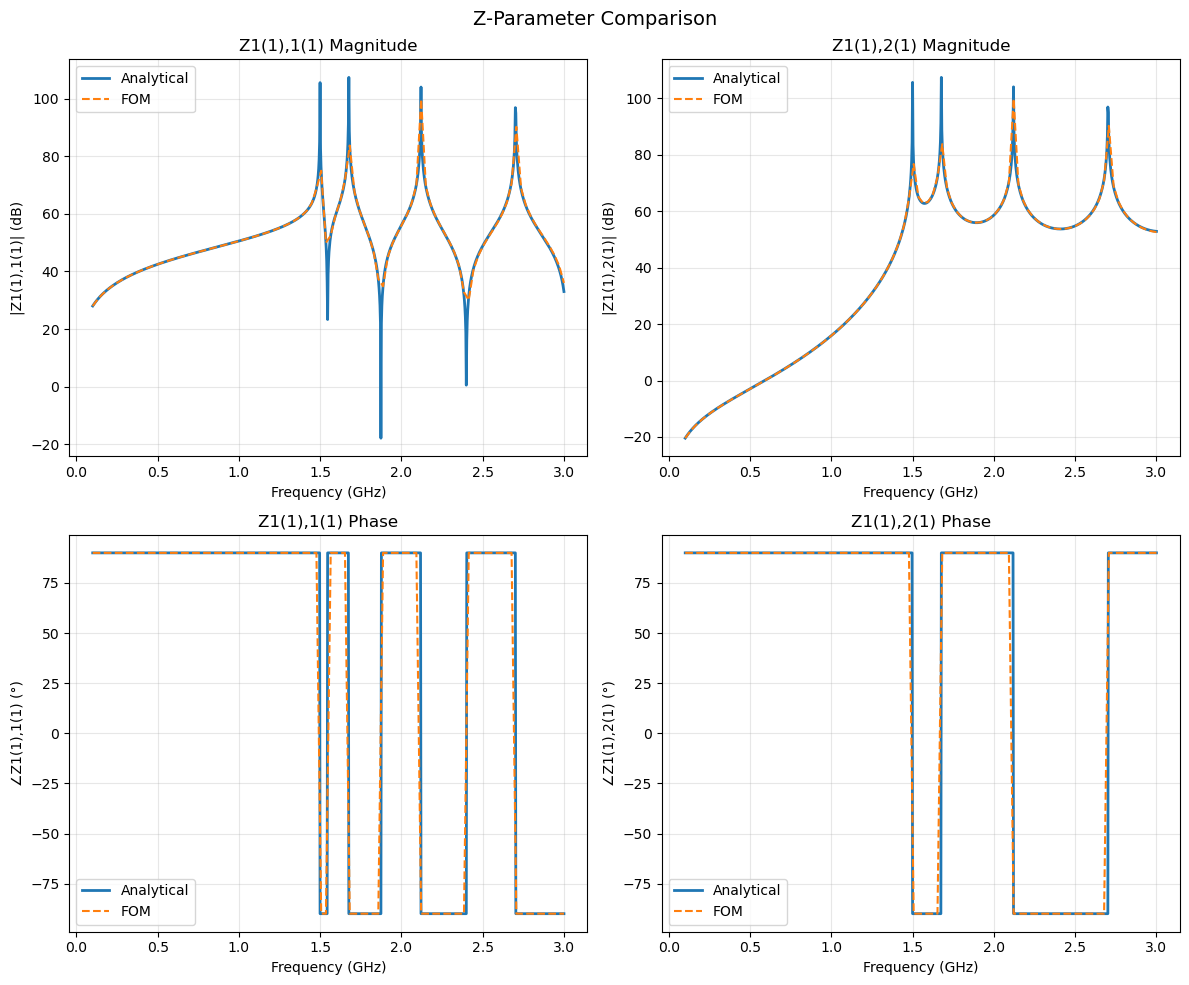

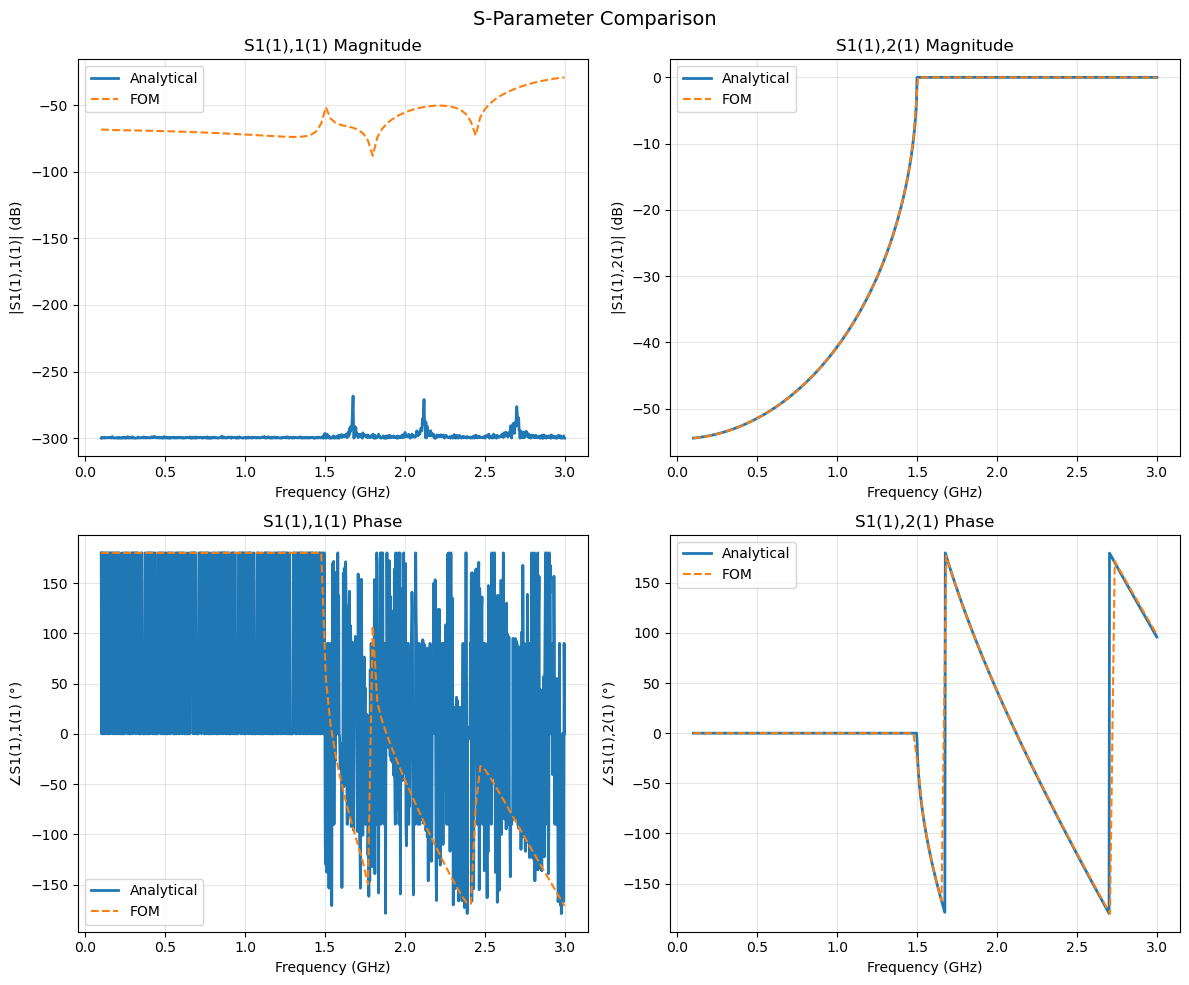

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [4]:
# 2. Analytical
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
analytical = RWGAnalytical(a=a, L=L)

# 3. FOM solve
fmin, fmax, nf = 0.1, 3, 100
fds = FrequencyDomainSolver(rwg, order=3)
fds.assemble_matrices(nportmodes=2)

fds.solve(fmin, fmax, nf, store_snapshots=True, solver_type='iterative')

# 4. Quick comparison plots - just pass the objects!
frequencies = np.linspace(fmin, fmax, 1000) * 1e9
plot_z_comparison([analytical, fds], frequencies=frequencies)
plot_s_comparison([analytical, fds], frequencies=frequencies)

In [5]:
fds.port_solver.port_orientation_factors

{'port1': 1.0, 'port2': -1.0}

In [6]:
fds.plot_port_mode('port1')


Port Mode: port1 [external (input)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [7]:
fds.plot_port_mode('port2')


Port Mode: port2 [external (output)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [8]:
fds.plot_field(14)


Field visualization at f = 0.5101 GHz
Source: global
Excitation: port1, mode 0
Plotting: |E| (None)


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

CPU times: total: 0 ns
Wall time: 0 ns

Model Order Reduction

Domain: vacuum
  Using global snapshots (single-domain structure)
  Full DOFs: 1428
  Snapshots: 400
  Reduced DOFs: 28
  Compression: 98.0%
  Singular value decay: 1.78e+06 → 1.40e+00

------------------------------------------------------------
Total: 1428 → 28 DOFs
Overall compression: 98.0%
CPU times: total: 891 ms
Wall time: 1.14 s
CPU times: total: 18 s
Wall time: 7.47 s


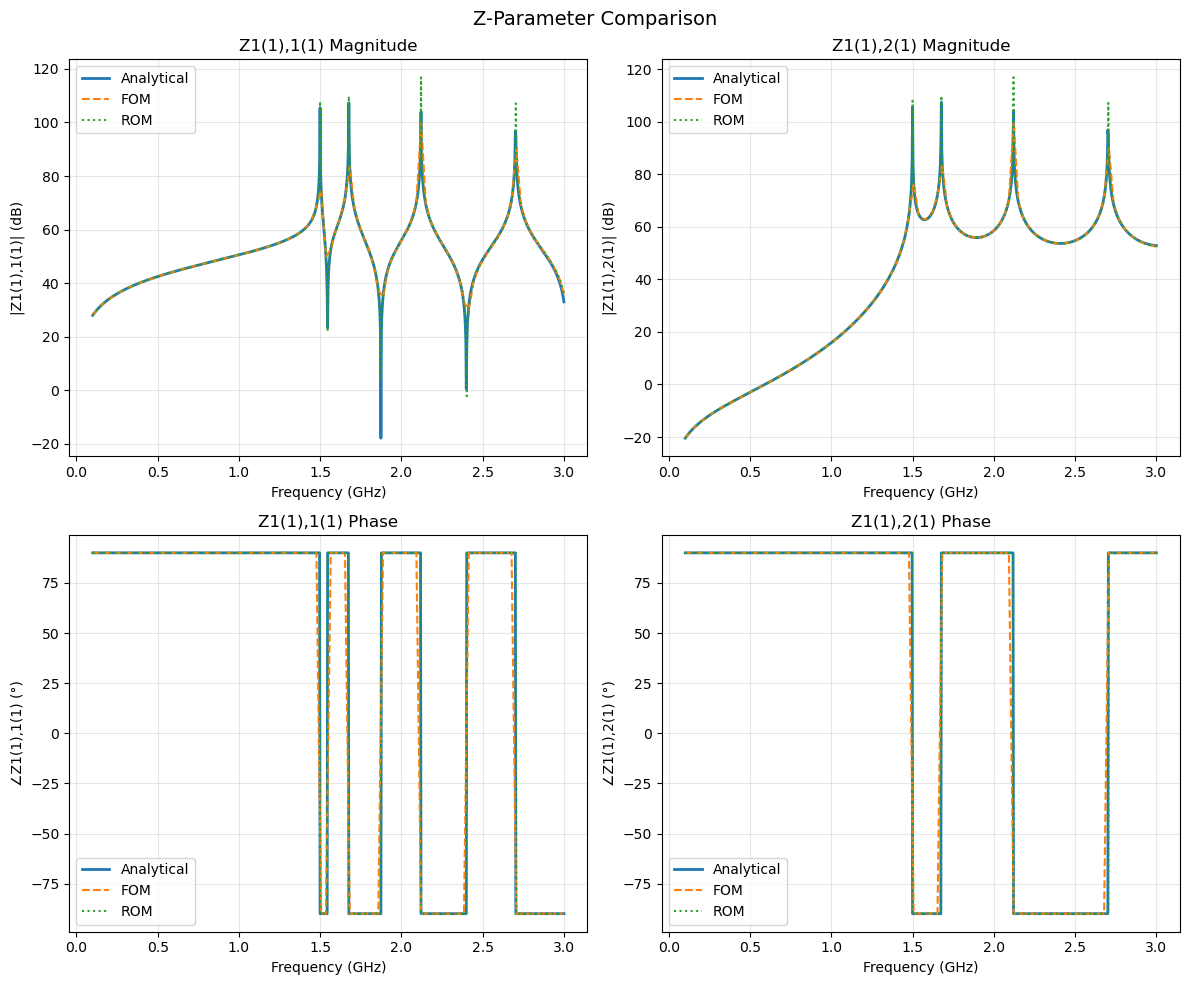

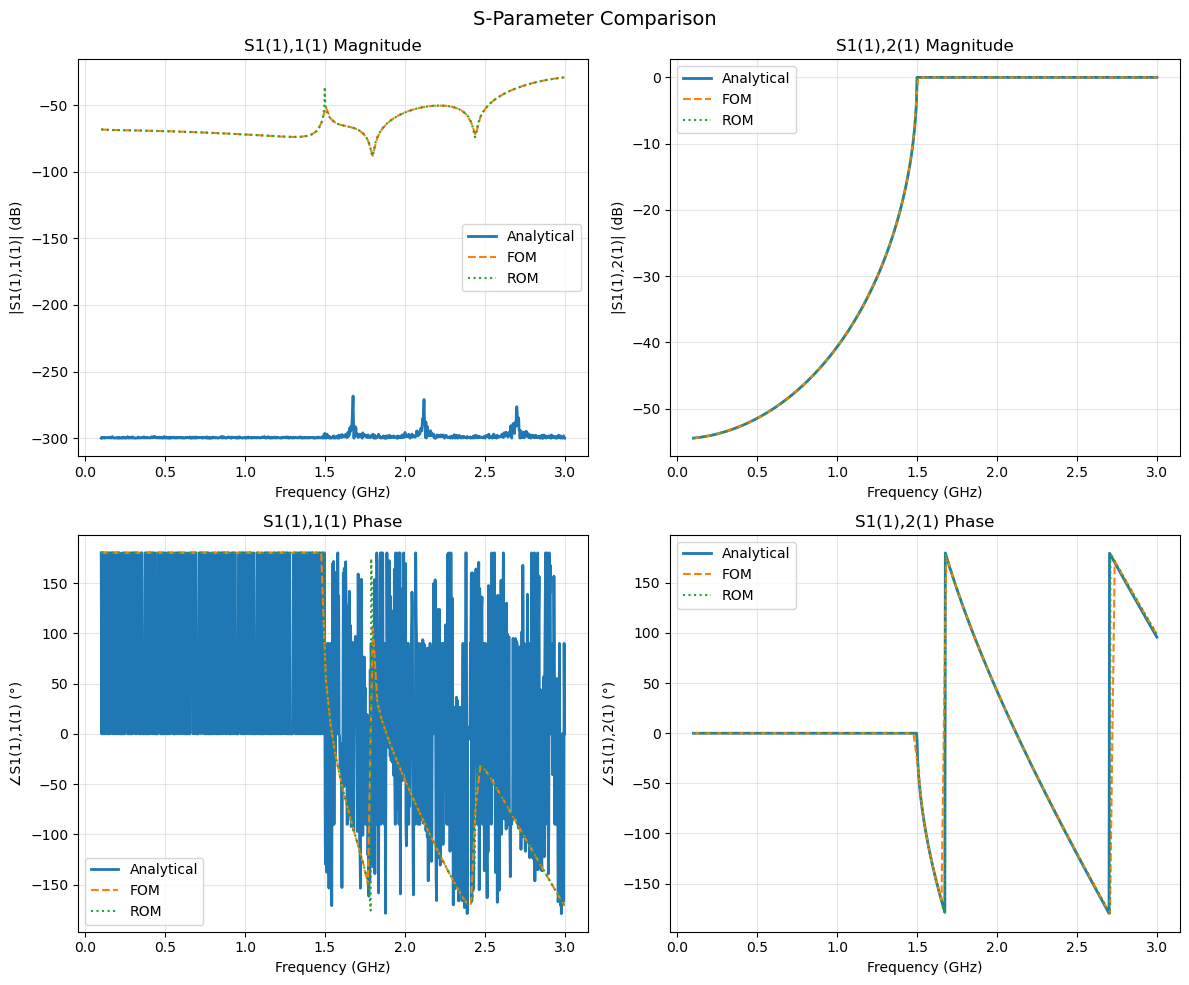

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [9]:
# After ROM is working...
from rom.reduction import ModelOrderReduction

%time rom = ModelOrderReduction(fds)
%time rom.reduce(max_rank=100, tol=1e-6)
%time rom.solve(fmin, fmax, 1000)

# Compare all three
plot_z_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])
plot_s_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])


## New Result-Object API

The new API provides a navigable object graph:
- `fds.fom` — global FOM result
- `fds.fom.rom` — ROM of the global FOM
- `fds.foms` — per-domain FOMs (multi-solid only)
- `fds.foms.roms.concat.rom` — full ROM concatenation chain

Each result object has `.plot_s()`, `.plot_z()`, `.plot_eigenvalues()` methods.

FOMResult(domain='global', n_ports=2, n_freq=100)

Model Order Reduction

Domain: vacuum
  Using global snapshots (single-domain structure)
  Full DOFs: 1428
  Snapshots: 400
  Reduced DOFs: 28
  Compression: 98.0%
  Singular value decay: 1.78e+06 → 1.40e+00

------------------------------------------------------------
Total: 1428 → 28 DOFs
Overall compression: 98.0%
ROMResult(domain='global', n_ports=2, n_freq=100)


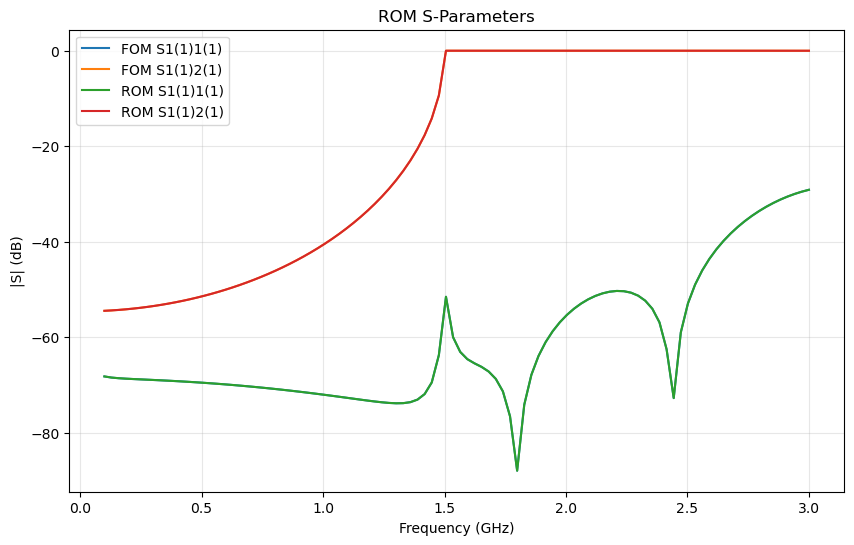

In [10]:
# === New API: result-object navigation ===

# FOM result — same data as fds, but as a standalone result object
fom_result = fds.fom
print(fom_result)

# Plot S-parameters directly from the FOM result
fig, ax = fom_result.plot_s(params=['1(1)1(1)', '1(1)2(1)'], label='FOM')

# ROM result — navigate from FOM
rom_result = fds.fom.rom
print(rom_result)

# Overlay ROM onto the same axes
fig, ax = rom_result.plot_s(params=['1(1)1(1)', '1(1)2(1)'], ax=ax, label='ROM')
plt.show()

(1.0, 5.0)

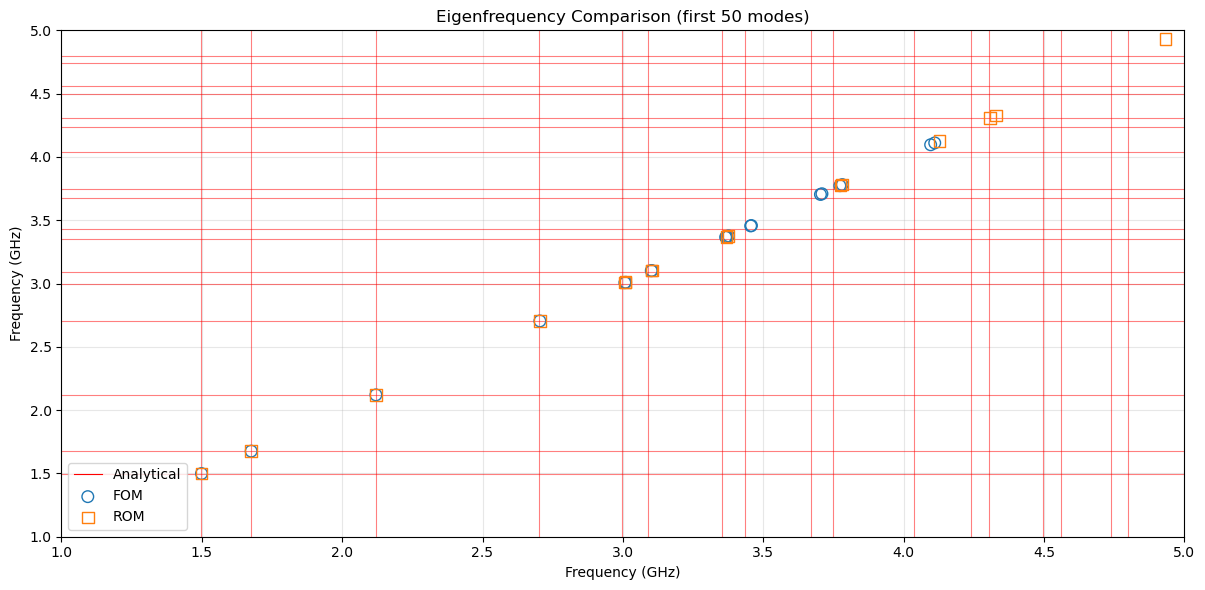

In [11]:
fig, ax = plot_eigenfrequencies([fds, rom], analytical=analytical,
                      labels=['FOM', 'ROM'], n_modes=50)
ax.set_ylim(1, 5)
ax.set_xlim(1, 5)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'global Solver Convergence'}, xlabel='Frequency (GHz)', ylabel='GMRES Iterations'>)

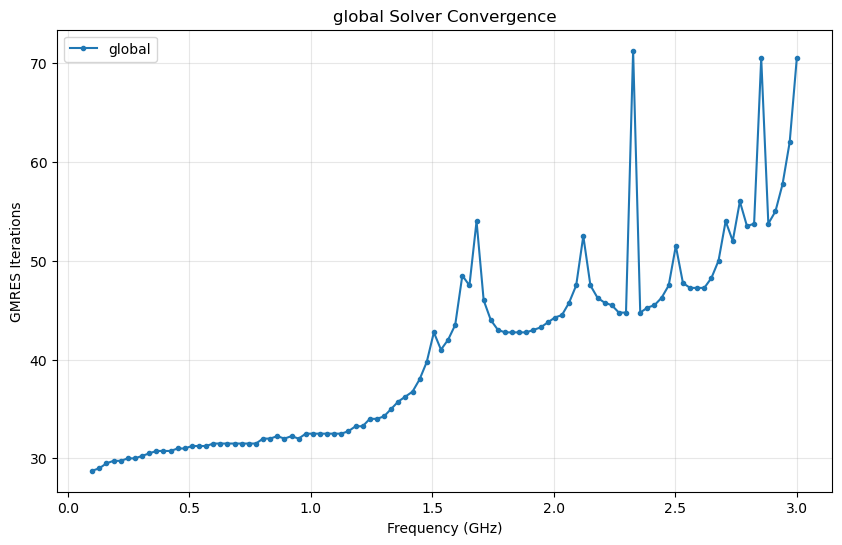

In [18]:
fds.fom.plot_residual('iterations')